In [1]:
import hoda
import tensorly as tl
import mne
mne.set_log_level('ERROR')
tl.set_backend('cupy')
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
epochs

Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.781 s
Baseline,off


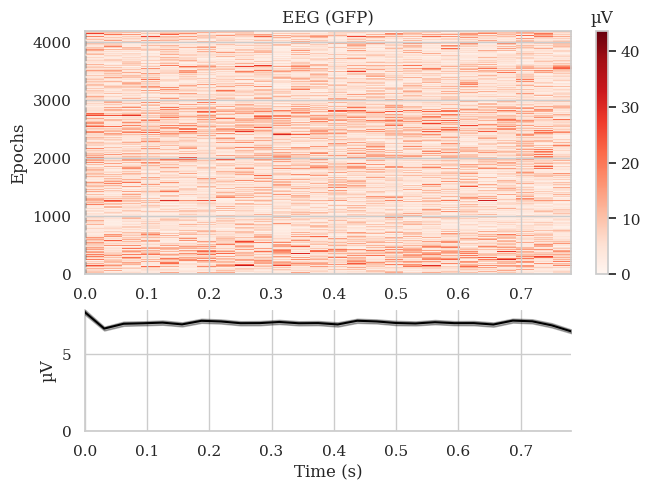

[<Figure size 640x480 with 3 Axes>]

In [4]:
epochs.plot_image()

In [5]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
4195,1,0,0
4196,1,0,0
4197,1,0,0
4198,1,0,0


In [6]:
X = epochs.get_data()
y = labels

X.shape

(4200, 8, 26)

In [7]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter, force_toeplitz,center
import warnings


from hoda.hoda import f_oneway, mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
    rank=3,
    max_iter=32,
    tol=1e-20,
    init ='svd',
    shrinkage='lw',
    toeplitz=None,
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=False,
    verbose=True,

)


%lprun -f hoda.fit hoda.fit(X,y)

Fitting discriminative Tucker model of rank (3, 3)...


  0%|          | 0/32 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 0.729073 s
File: /project/src/hoda/hoda.py
Function: fit at line 251

Line #      Hits         Time  Per Hit   % Time  Line Contents
   251                                               def fit(self, X, y):
   252                                                   # Setup
   253         1       8188.0   8188.0      0.0          if not tl.is_tensor(X):
   254         1   69342081.0    7e+07      9.5              X = tl.tensor(X, dtype=X.dtype)
   255                                           
   256         1     407503.0 407503.0      0.1          self.classes_, class_counts = np.unique(y, return_counts=True)
   257         1     910523.0 910523.0      0.1          class_counts = tl.tensor(class_counts)
   258         1       4014.0   4014.0      0.0          n_samples, *shape = X.shape
   259         1        656.0    656.0      0.0          order = len(shape)
   260                                           
   261                                      

In [8]:
hoda.train_info_

,iteration,mode,update,shrinkage,objective
0,1.0,0.0,8.161391e-02,0.000300,1.981484e-07
1,1.0,1.0,2.618079e-02,0.021935,2.583475e-07
2,2.0,0.0,8.439797e-02,0.000400,2.487597e-07
3,2.0,1.0,1.715955e-02,0.011435,2.512819e-07
4,3.0,0.0,1.831861e-02,0.000393,2.332584e-07
5,3.0,1.0,1.734086e-02,0.010756,2.910821e-07
6,4.0,0.0,8.432697e-04,0.000325,2.154419e-07
7,4.0,1.0,1.707385e-02,0.009207,3.031694e-07
8,5.0,0.0,2.674320e-05,0.000319,2.113059e-07
9,5.0,1.0,1.878344e-07,0.008908,3.050907e-07


<Axes: xlabel='iteration', ylabel='objective'>

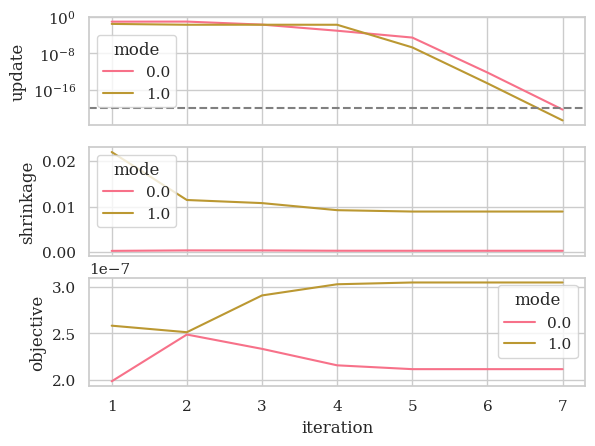

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3,1, sharex=True)
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[2])


In [10]:
if hoda.extra_train_info:
    fig, axs = plt.subplots(7,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', hue='mode', ax=axs[2])
    #axs[2].set(yscale="log")
    #axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='log_like', hue='mode', ax=axs[3])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='bic', hue='mode', ax=axs[4])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aic', hue='mode', ax=axs[5]) 
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aicc', hue='mode', ax=axs[6])



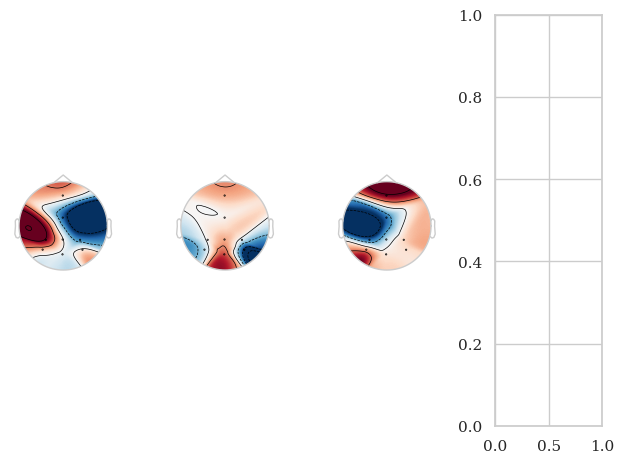

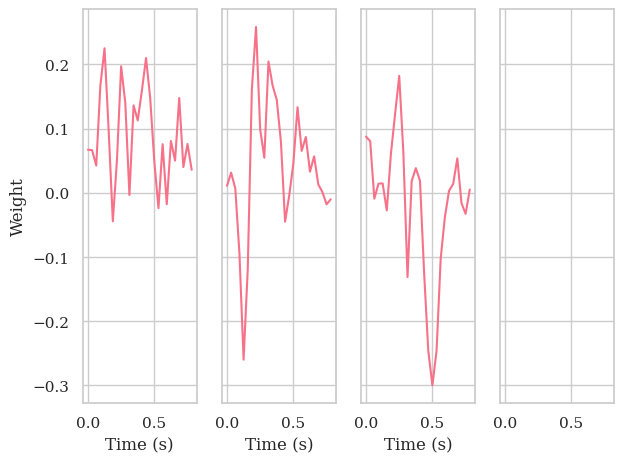

In [11]:

import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.weights_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


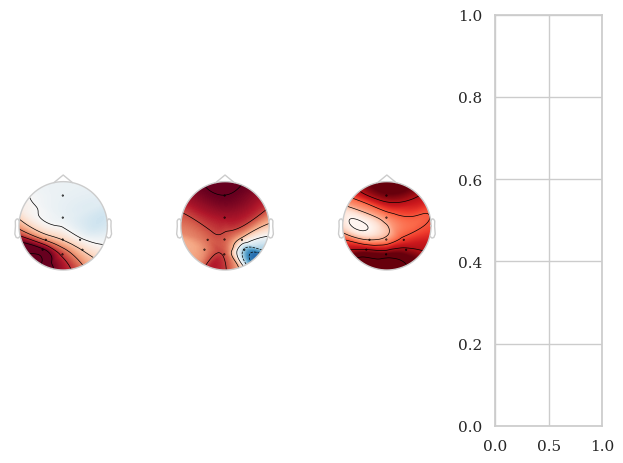

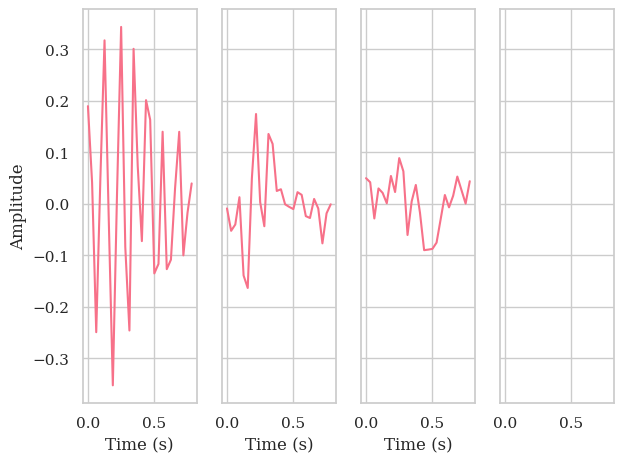

In [12]:

n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


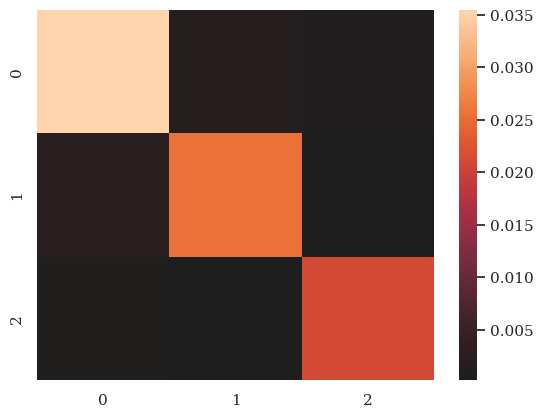

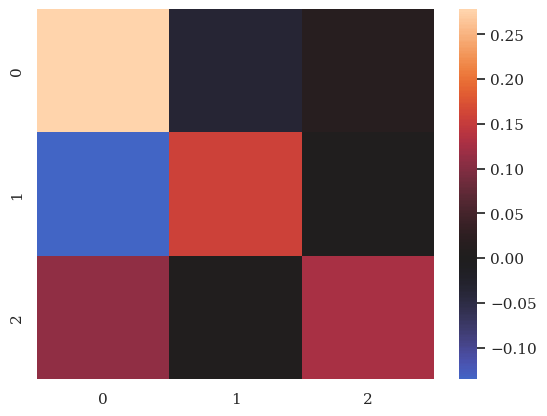

In [13]:
for k in range(2):
    sns.heatmap(tl.to_numpy(hoda.weights_[k].T@ hoda.aps_[k]), center=0)
    plt.show()


In [14]:
Xt = hoda.transform(X)

<BarContainer object of 3 artists>

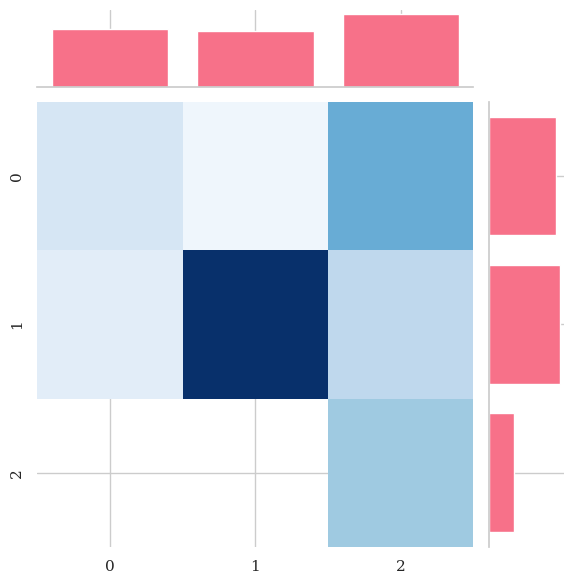

In [15]:
from hoda.hoda import f_multiway

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)



In [16]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(4200, 9)

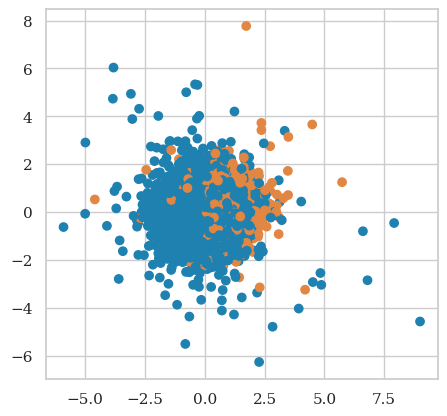

In [17]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

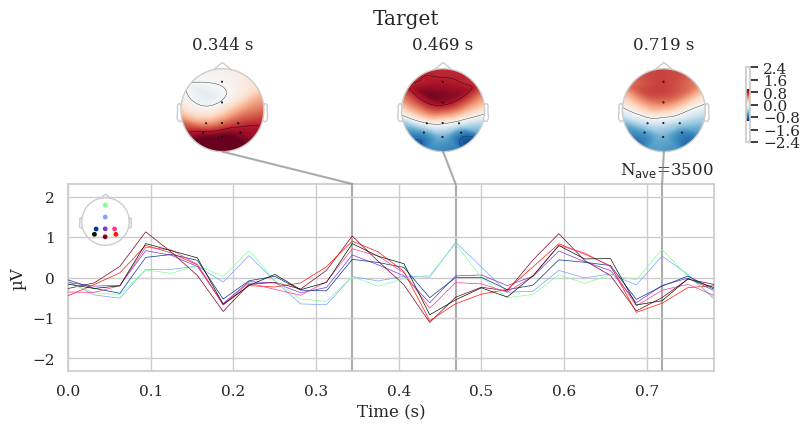

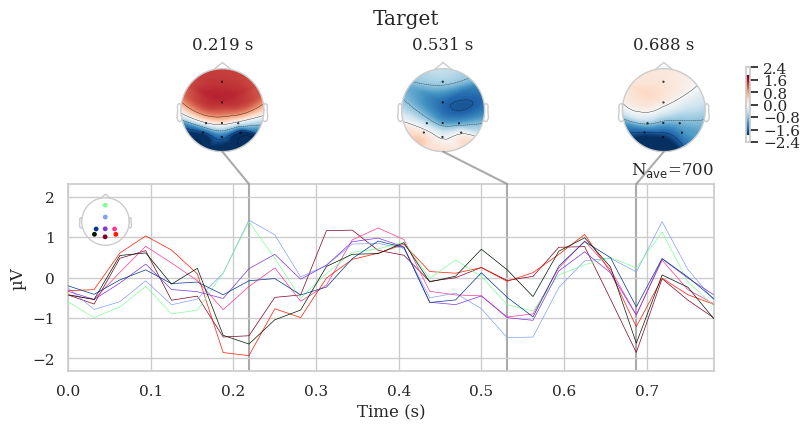

In [18]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

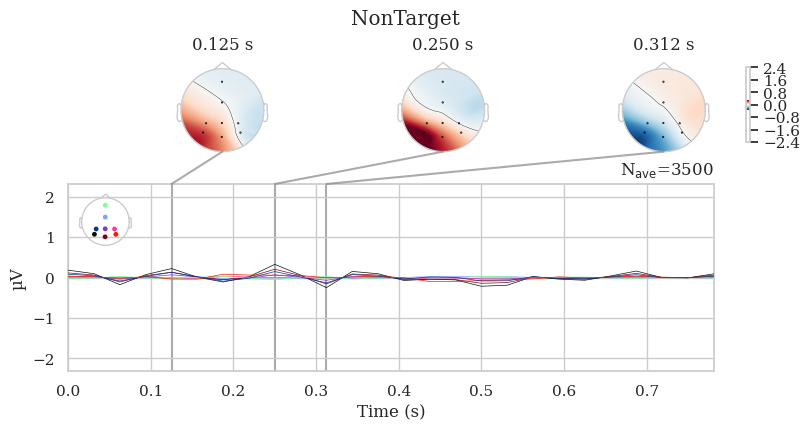

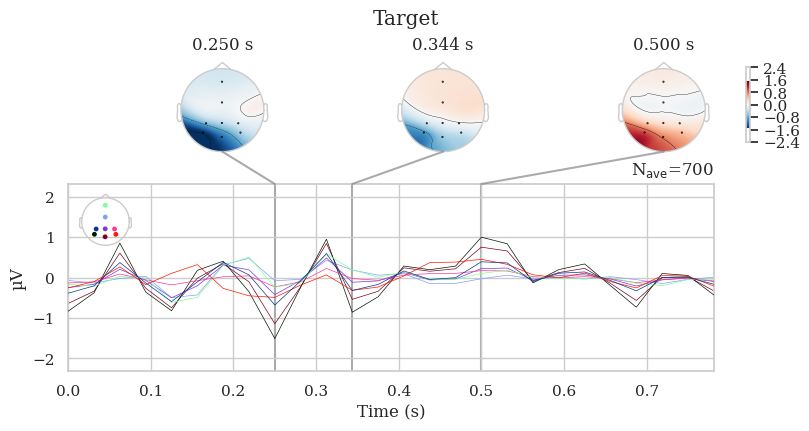

In [19]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,**joint_args)
    else:
        evoked_rec.plot(**ts_args)

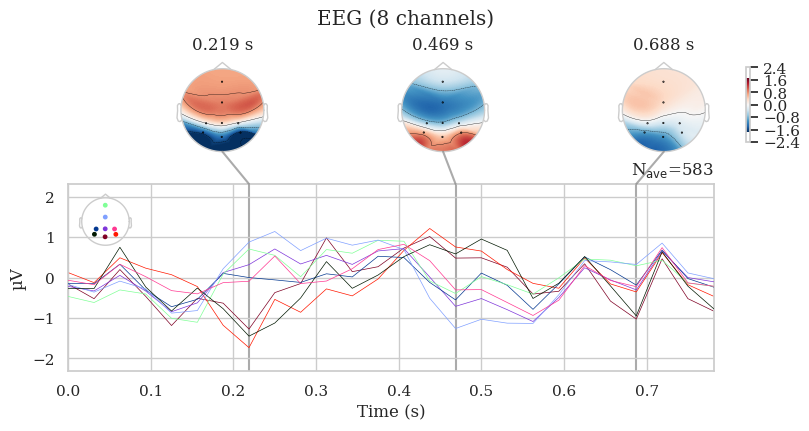

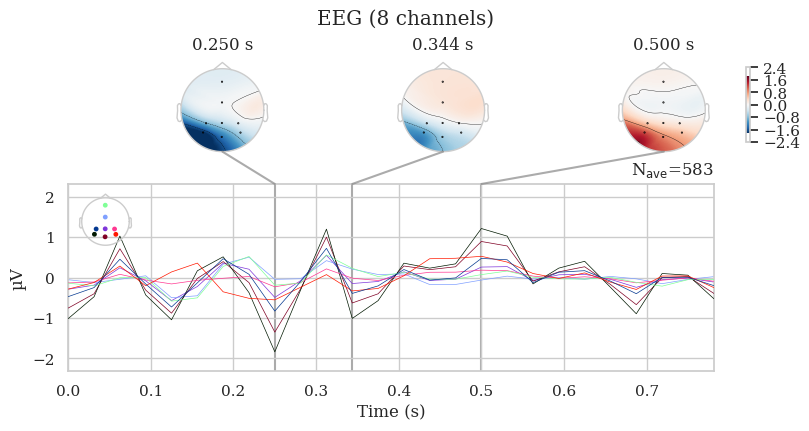

In [20]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


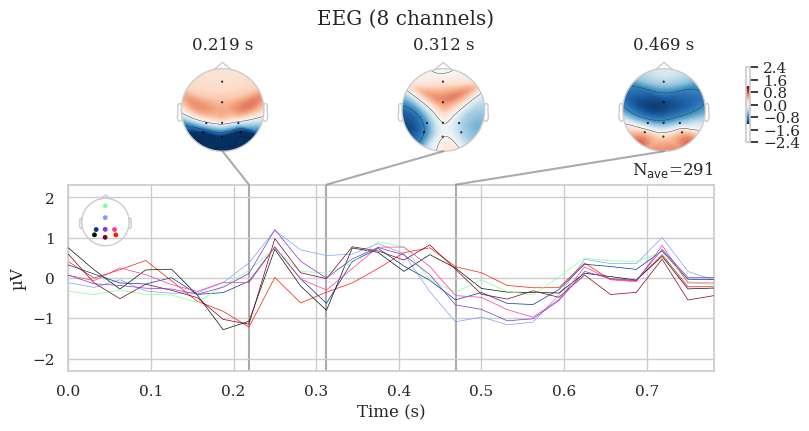

In [21]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)